In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Load the Iris Dataset

In [8]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)


Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']


In [9]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["species"] = y
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


Exploratory Data Analysis

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


In [11]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [12]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [13]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Visualisations

In [14]:
print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


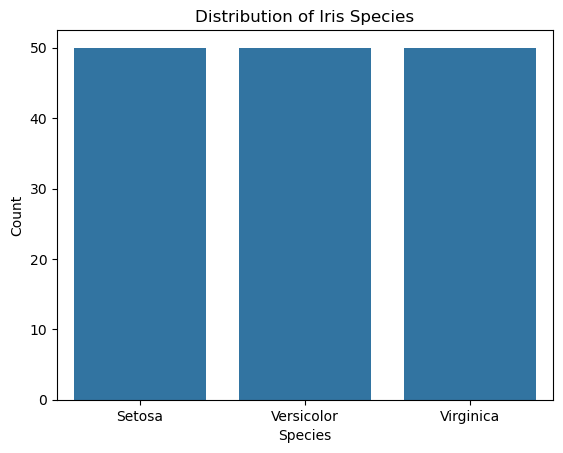

In [15]:
sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

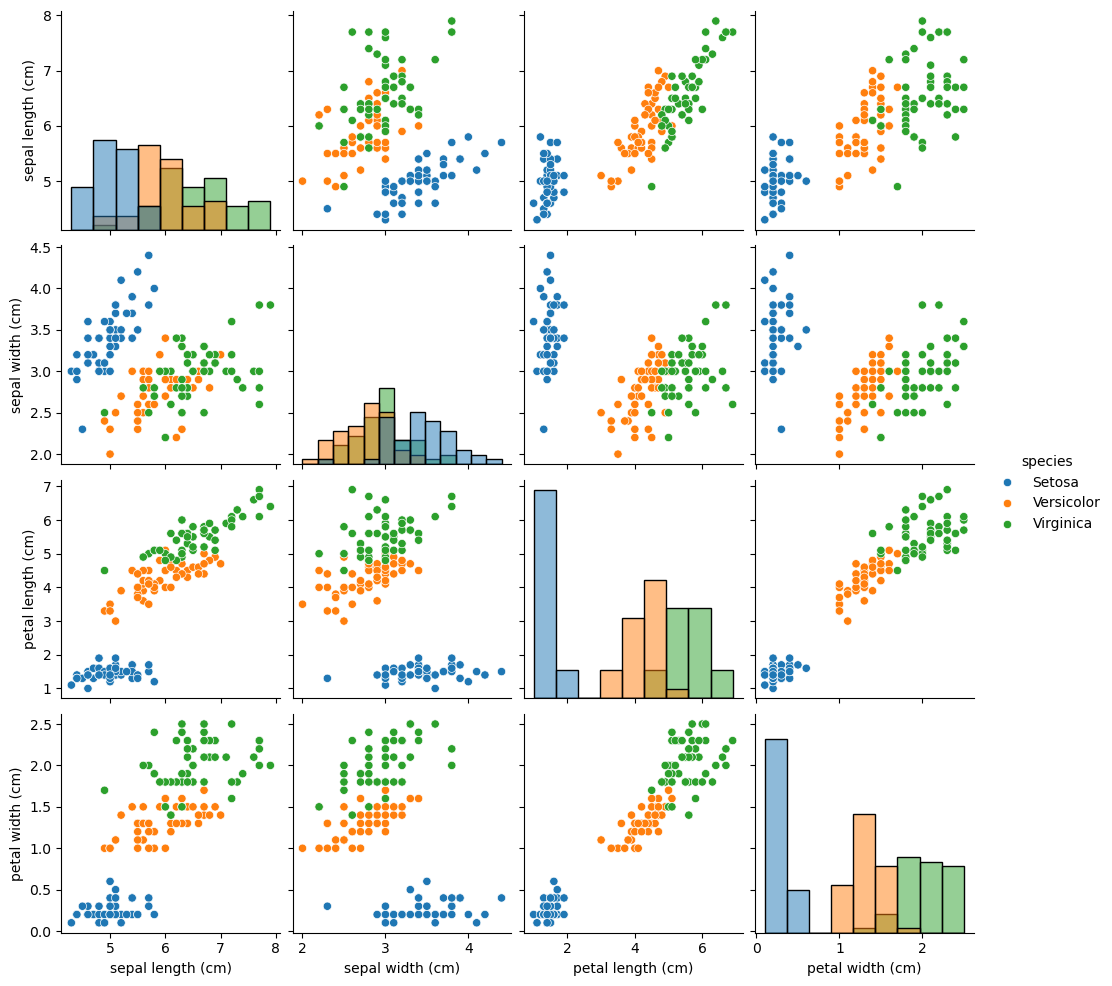

In [16]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

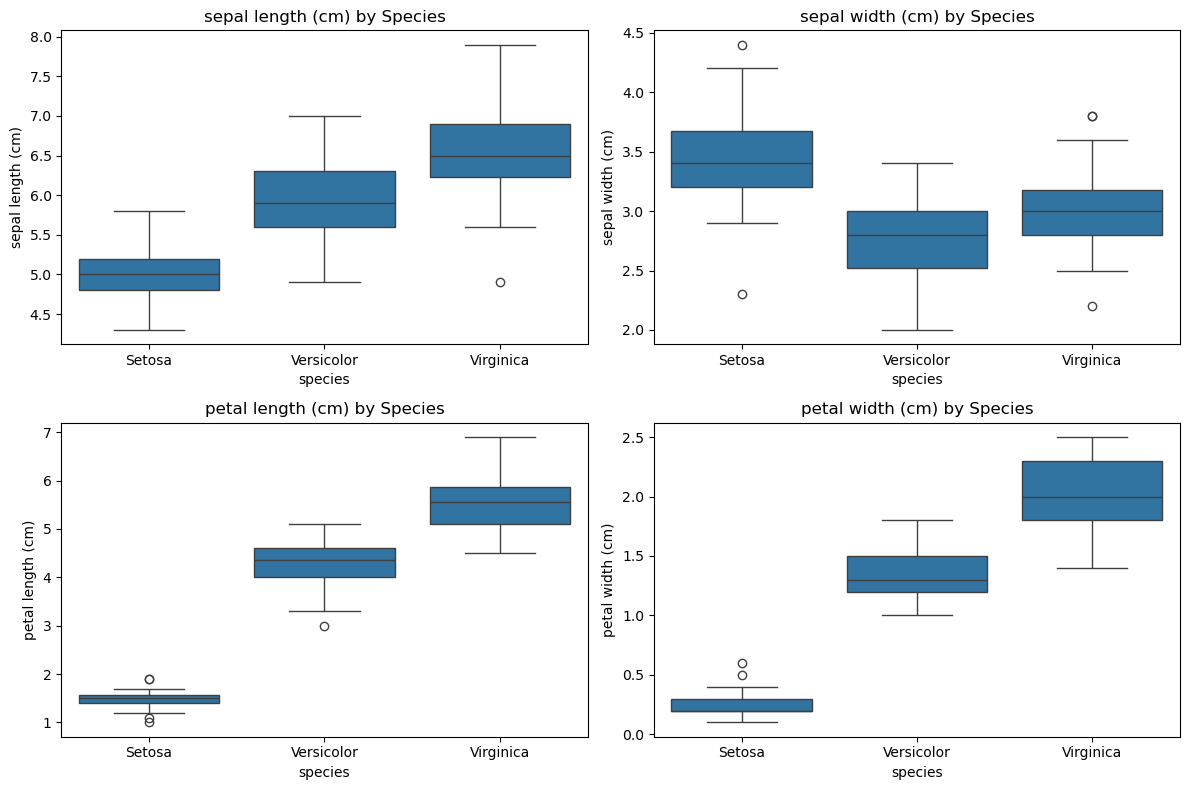

In [17]:
features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")

plt.tight_layout()
plt.show()

Feature selection

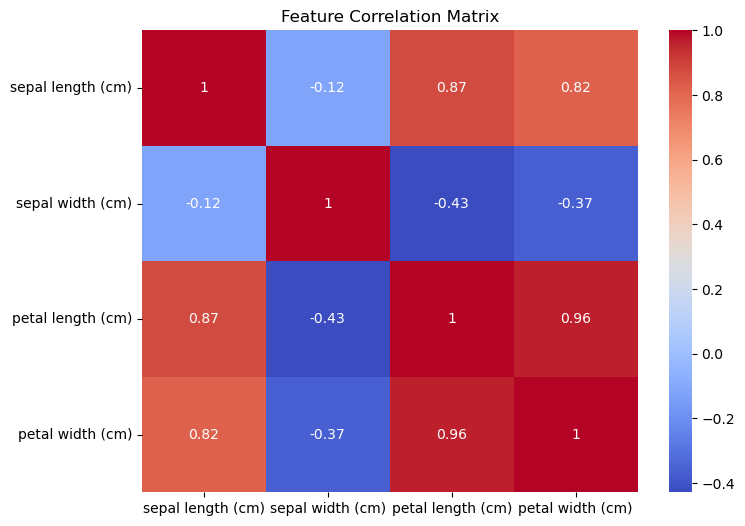

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.drop(columns="species").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

Train/Test Split

In [19]:
X = df.drop(columns="species")
y = df["species"]


In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model 1 — Logistic Regression

In [23]:
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [24]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

Logistic Regression Accuracy: 0.9333333333333333


In [25]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



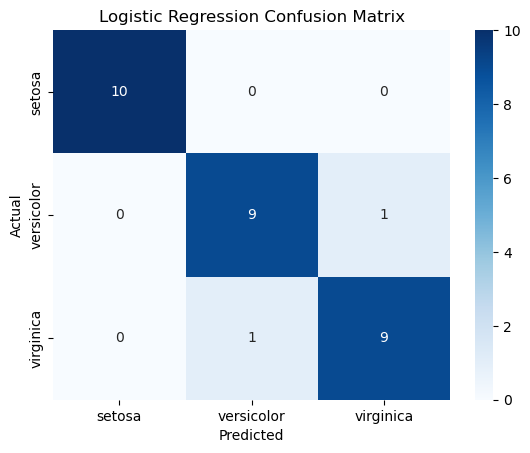

In [26]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Model 2 — K-Nearest Neighbours

In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(X_test_scaled)

In [28]:
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9333333333333333


In [29]:
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



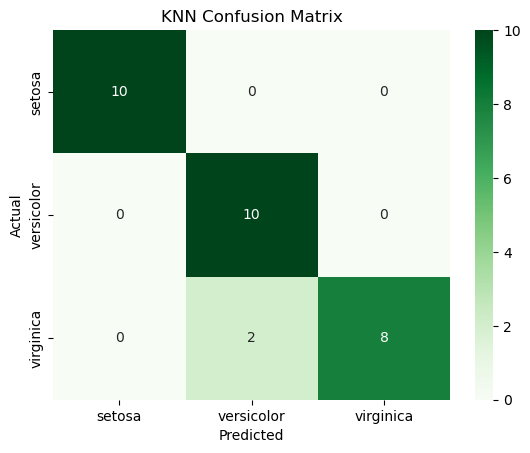

In [30]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

Model comparision

In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,KNN,0.933333


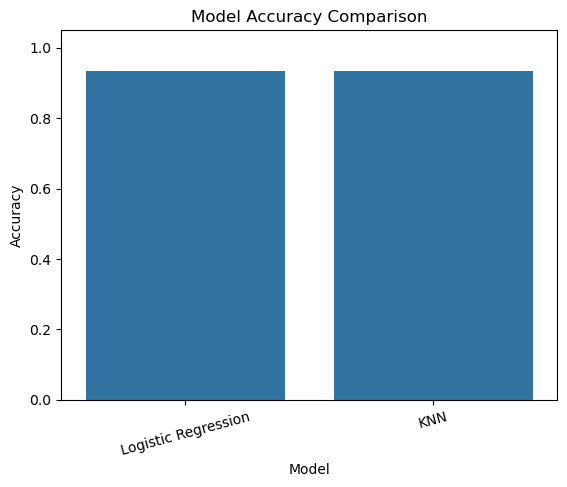

In [33]:
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

BEST MODEL

In [34]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Logistic Regression
Accuracy               0.933333
Name: 0, dtype: object


In [35]:
new_flower = [[
    5.1,   # sepal length
    3.5,   # sepal width
    1.4,   # petal length
    0.2    # petal width
]]

new_flower_scaled = scaler.transform(new_flower)

prediction = logistic_model.predict(new_flower_scaled)

print(
    "Predicted Species:",
    iris.target_names[prediction[0]]
)

Predicted Species: setosa


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
